Hind Ahmed Aljasmi

Method: Gaussian Mixture Model (GMM)

Implementing GMM clustering on PCA-transformed building energy data, evaluates the clusters quality by using standard metrics, and benchmarks results against global and facility-type baselines.

Installing necessary libraries and importing them:

In [5]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q
#Importing the neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Importing GMM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')
PALETTE = sns.color_palette('tab10')

Loading the Datasets:

In [6]:
# loading the datasets
pca_data          = pd.read_csv('pca_data.csv')
clean_data        = pd.read_csv('clean_data.csv')
global_baseline   = pd.read_csv('global_baseline.csv', index_col=0)
facility_baseline = pd.read_csv('facility_baseline.csv')
# Displaying the data
print(f'pca_data          : {pca_data.shape}   columns: {pca_data.columns.tolist()}')
print(f'clean_data        : {clean_data.shape}   columns: {clean_data.columns.tolist()}')
print(f'global_baseline   :')
print(global_baseline)
print(f'\nfacility_baseline : {facility_baseline.shape}')
print(facility_baseline.head(3))

pca_data          : (135735, 9)   columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9']
clean_data        : (135735, 12)   columns: ['year', 'climate', 'building_class', 'facility_type', 'floor_area', 'year_built', 'energy_star_rating', 'electric_eui', 'fuel_eui', 'site_eui', 'source_eui', 'ghg_emissions_int']
global_baseline   :
                     Mean     Std
site_eui            86.44   51.20
source_eui         149.27  103.36
electric_eui        27.89   29.19
fuel_eui            58.24   40.04
ghg_emissions_int    5.97    3.90

facility_baseline : (58, 12)
                 facility_type  site_eui_mean  site_eui_std  source_eui_mean  \
0  Multifamily - Uncategorized          84.86         35.82           129.16   
1       Office - Uncategorized          77.69         42.43           175.52   
2  Education - Other classroom          71.32         32.62           136.35   

   source_eui_std  electric_eui_mean  electric_eui_std  fuel_eui_mean  \
0           50.48    

Selecting the Optimal Number of Clusters by using BIC / AIC methods:

BIC/AIC model selection on 20,000 sample rows ...
  k= 2  BIC=   111,012.2   AIC=   110,150.8
  k= 3  BIC=    75,080.6   AIC=    73,784.5
  k= 4  BIC=    43,020.4   AIC=    41,289.6
  k= 5  BIC=    15,403.2   AIC=    13,237.6
  k= 6  BIC=   -11,886.9   AIC=   -14,487.1
  k= 7  BIC=   -33,819.4   AIC=   -36,854.3
  k= 8  BIC=   -55,393.7   AIC=   -58,863.3
  k= 9  BIC=   -57,292.7   AIC=   -61,197.0
  k=10  BIC=   -65,830.7   AIC=   -70,169.7


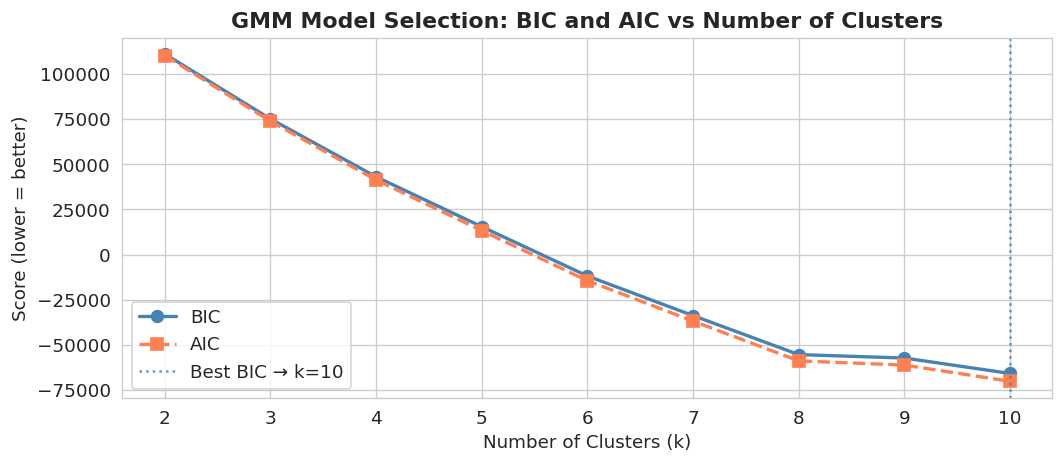


Optimal k (lowest BIC) = 10


In [7]:
X = pca_data.values  # Convert PCA data to a NumPy array for GMM input. Shape: (135735, 9)

# Subsample for speed during model selection. Using a smaller subset will help in reducing computation time.
SAMPLE_N  = 20000  # Number of samples to use for model selection

# Generating a random indices to select a subset of the data without replacement
idx_s     = np.random.default_rng(42).choice(len(X), size=SAMPLE_N, replace=False)
X_sample  = X[idx_s]  # Extracting the subsampled data

# Define the range of clusters (k) to evaluate
k_range    = range(2, 11)
bic_scores = []  # List to store Bayesian Information Criterion scores
aic_scores = []  # List to store Akaike Information Criterion scores

print(f'BIC/AIC model selection on {SAMPLE_N:,} sample rows ...')
# Iterate through each number of clusters in the defined range
for k in k_range:
    # Initialize GaussianMixture model with current k
    # random_state for reproducibility, max_iter for convergence, n_init to run multiple initializations
    g = GaussianMixture(n_components=k, covariance_type='full',
                        random_state=42, max_iter=300, n_init=3)
    g.fit(X_sample)  # Fit the GMM to the subsampled data
    bic_scores.append(g.bic(X_sample))  # Calculate and store BIC score
    aic_scores.append(g.aic(X_sample))  # Calculate and store AIC score
    print(f'  k={k:2d}  BIC={bic_scores[-1]:>12,.1f}   AIC={aic_scores[-1]:>12,.1f}')

# Determining the optimal number of clusters based on the lowest BIC and AIC scores
# Adding 2 because k_range starts from 2
best_k_bic = int(np.argmin(bic_scores)) + 2
best_k_aic = int(np.argmin(aic_scores)) + 2

# Plot the BIC and AIC scores to visualize the optimal k
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, bic_scores, 'o-', label='BIC', color='steelblue', linewidth=2, markersize=7)
ax.plot(k_range, aic_scores, 's--', label='AIC', color='coral',    linewidth=2, markersize=7)
# Highlight the best k found by BIC on the plot
ax.axvline(best_k_bic, color='steelblue', linestyle=':', alpha=0.8, label=f'Best BIC → k={best_k_bic}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Score (lower = better)')
ax.set_title('GMM Model Selection: BIC and AIC vs Number of Clusters', fontweight='bold')
ax.set_xticks(list(k_range))
ax.legend() # Display the details for BIC and AIC
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show() # Display the plot

BEST_K = best_k_bic # Assign the optimal k (based on BIC) to a variable
print(f'\nOptimal k (lowest BIC) = {BEST_K}')

### Fitting Gaussian Mixture Model (GMM) to the full dataset

In [8]:
# Initialize and fit the GMM to the full PCA data using the optimal number of clusters (BEST_K)
gmm = GaussianMixture(n_components=BEST_K, covariance_type='full',
                      random_state=42, max_iter=300, n_init=3)

# Fit the GMM to the entire dataset (X)
gmm.fit(X)

# Predict the cluster labels for each data point in the full dataset
labels = gmm.predict(X)

# Add the cluster labels to the clean_data DataFrame for further analysis
clean_data['cluster'] = labels

# Display the first few rows of the clean_data DataFrame with the new cluster labels
print(f'Shape of clean_data with new cluster column: {clean_data.shape}')
print(f'Number of unique clusters: {clean_data["cluster"].nunique()}')
print('First 5 rows with cluster labels:')
display(clean_data.head())

Shape of clean_data with new cluster column: (135735, 13)
Number of unique clusters: 10
First 5 rows with cluster labels:


,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int,cluster
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099,2
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763,2
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479,2
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045,2
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263,2


### Evaluating Cluster Quality with Standard Metrics

In [9]:
# Calculate clustering metrics
silhouette = silhouette_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)

print(f'Silhouette Score: {silhouette:.3f}')
print(f'Davies-Bouldin Index: {davies_bouldin:.3f}')
print(f'Calinski-Harabasz Score: {calinski_harabasz:.3f}')

Silhouette Score: 0.005
Davies-Bouldin Index: 6.322
Calinski-Harabasz Score: 5925.485


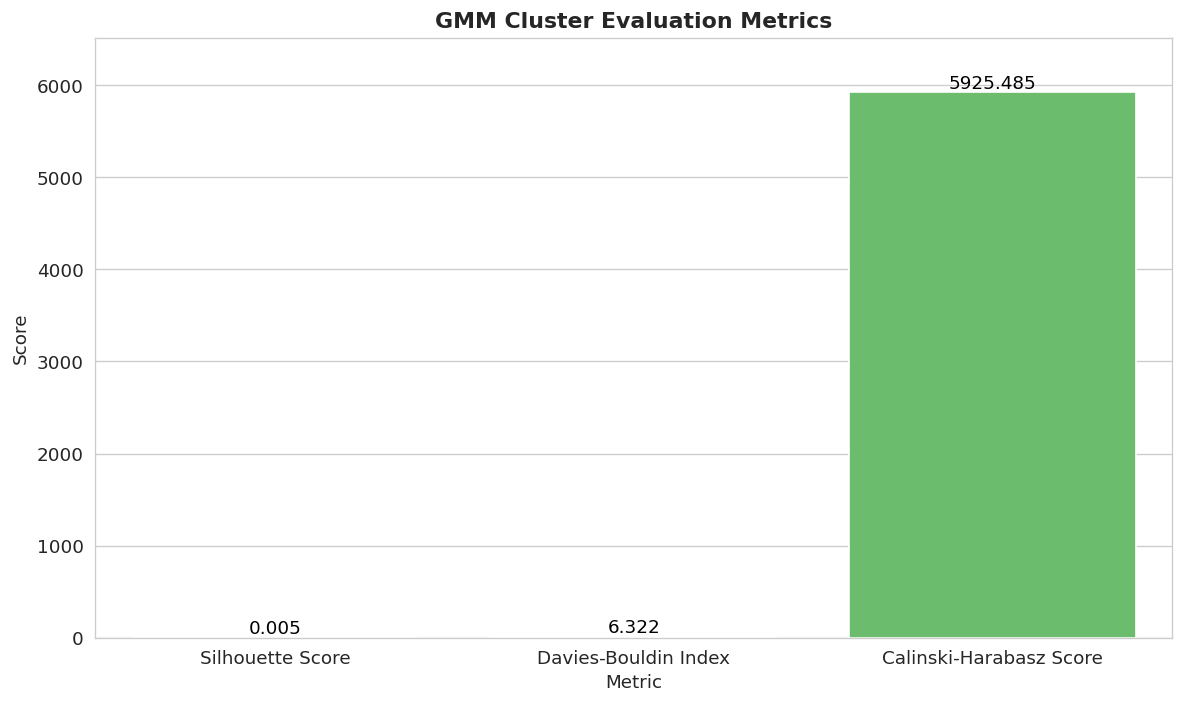

In [10]:
# Create a DataFrame for the evaluation metrics
metrics_df = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score'],
    'Score': [silhouette, davies_bouldin, calinski_harabasz]
})

# Create a bar plot to visualize the metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df, palette='viridis')
plt.title('GMM Cluster Evaluation Metrics', fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, max(metrics_df['Score']) * 1.1) # Set y-axis limit slightly above max score

# Add score values on top of the bars
for index, row in metrics_df.iterrows():
    plt.text(index, row['Score'], f'{row['Score']:.3f}', color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

### Re-fitting GMM with `n_components=4` to improve all the evaluation metrics

In [11]:
# Define a new number of components to try
NEW_K = 4
print(f'Attempting GMM with n_components = {NEW_K}')

# Initialize and fit the GMM to the full PCA data with the new K
gmm_new = GaussianMixture(n_components=NEW_K, covariance_type='full',
                          random_state=42, max_iter=300, n_init=3)

# Fit the GMM to the entire dataset (X)
gmm_new.fit(X)

# Predicting the cluster labels for each data point in the full dataset
labels_new = gmm_new.predict(X)

# Add the new cluster labels to the clean_data DataFrame for further analysis
# We'll create a new column to compare with the previous clustering
clean_data['cluster_k4'] = labels_new

print(f'Shape of clean_data with new cluster column: {clean_data.shape}')
print(f'Number of unique clusters: {clean_data["cluster_k4"].nunique()}')
print('First 5 rows with new cluster labels:')
display(clean_data.head())

Attempting GMM with n_components = 4
Shape of clean_data with new cluster column: (135735, 14)
Number of unique clusters: 4
First 5 rows with new cluster labels:


,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int,cluster,cluster_k4
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099,2,0
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763,2,0
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479,2,0
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045,2,0
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263,2,0


### Evaluating Cluster Quality with Standard Metrics for `n_components=4`

In [12]:
# Calculate clustering metrics for the new model
silhouette_new = silhouette_score(X, labels_new)
davies_bouldin_new = davies_bouldin_score(X, labels_new)
calinski_harabasz_new = calinski_harabasz_score(X, labels_new)

print(f'Silhouette Score (k={NEW_K}): {silhouette_new:.3f}')
print(f'Davies-Bouldin Index (k={NEW_K}): {davies_bouldin_new:.3f}')
print(f'Calinski-Harabasz Score (k={NEW_K}): {calinski_harabasz_new:.3f}')

Silhouette Score (k=4): 0.104
Davies-Bouldin Index (k=4): 3.065
Calinski-Harabasz Score (k=4): 11388.529


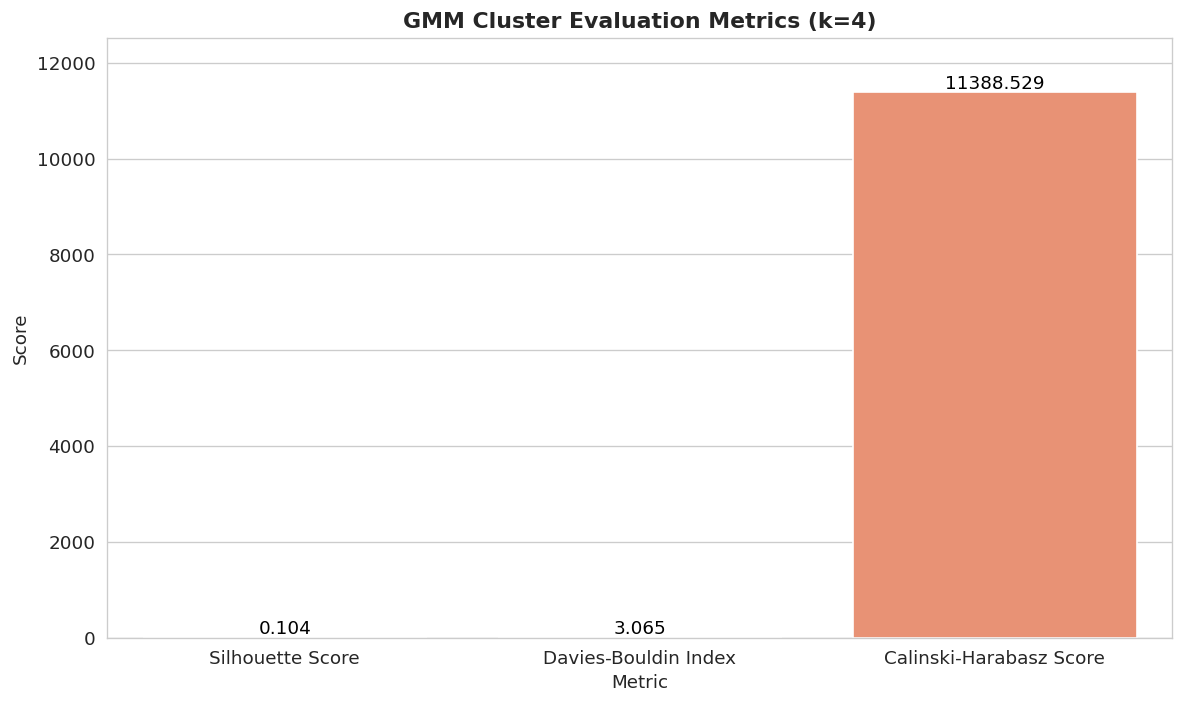

In [13]:
# Creating a DataFrame for the evaluation metrics (new model)
metrics_df_new = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Score'],
    'Score': [silhouette_new, davies_bouldin_new, calinski_harabasz_new]
})

# Creating a bar plot to visualize the new metrics
plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', data=metrics_df_new, palette='magma')
plt.title(f'GMM Cluster Evaluation Metrics (k={NEW_K})', fontweight='bold')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.ylim(0, max(metrics_df_new['Score']) * 1.1) # Set y-axis limit slightly above max score

# Adding score values on top of the bars
for index, row in metrics_df_new.iterrows():
    plt.text(index, row['Score'], f'{row['Score']:.3f}', color='black', ha="center", va='bottom')

plt.tight_layout()
plt.show()

### Visualizing Clusters (k=4)

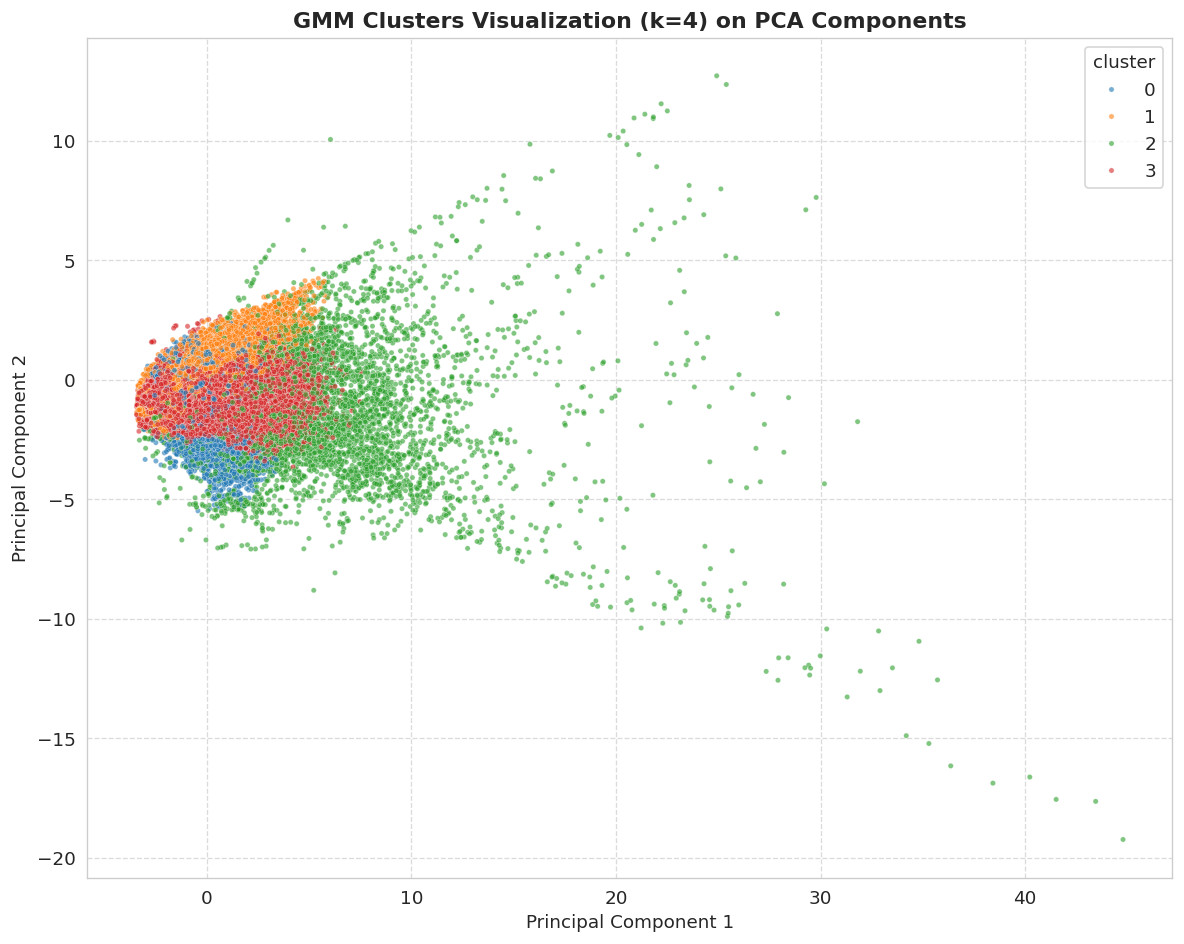

In [15]:
# Combine PCA data with cluster labels for plotting
plot_df = pd.DataFrame(X[:, :2], columns=['PC1', 'PC2'])
plot_df['cluster'] = clean_data['cluster_k4']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=plot_df,
    palette=PALETTE, legend='full', alpha=0.6, s=10
)
plt.title(f'GMM Clusters Visualization (k={NEW_K}) on PCA Components', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Reducing the number of clusters to 3 has improved the model and improved our evaluation metrics:

Silhouette Score: This has improved from 0.005 (with k=10) to 0.104 (with k=4). While still a relatively low score, it indicates a slight improvement in the separation and definition of the clusters.

Davies-Bouldin Index: This score has significantly decreased from 6.322 (with k=10) to 3.065 (with k=4). A lower Davies-Bouldin Index is better, meaning the clusters are now more compact and better separated from each other.

Calinski-Harabasz Score: This score has increased from 5925.485 (with k=10) to 11388.529 (with k=4). A higher score is generally preferred, suggesting better-defined clusters.

computing the mean and std for site_eui and ghg_emissions_int for each cluster:

In [17]:
# Define the energy metrics for this specific benchmarking
benchmarking_metrics = ['site_eui', 'ghg_emissions_int']

# Group clean_data by the new cluster labels (k=5) and calculate descriptive statistics
cluster_summary_benchmarking = clean_data.groupby('cluster_k4')[benchmarking_metrics].agg(['mean', 'std'])

# Flatten the multi-index columns for easier readability
cluster_summary_benchmarking.columns = ['_'.join(col).strip() for col in cluster_summary_benchmarking.columns.values]

print('Cluster Summary Statistics (k=4) for Benchmarking Metrics:')
display(cluster_summary_benchmarking)

Cluster Summary Statistics (k=4) for Benchmarking Metrics:


,site_eui_mean,site_eui_std,ghg_emissions_int_mean,ghg_emissions_int_std
cluster_k4,,,,
0,78.330331,25.917737,5.071275,2.337079
1,84.491882,30.603500,5.553816,1.961126
2,193.593886,138.374589,15.402949,10.268164
3,74.798415,41.005674,5.533151,3.049754


Compare the clusters statistics with the Global baseline to understand how the clusters perform relative to the overall dataset.

Comparison with Global Baseline (Benchmarking Metrics):


,site_eui_mean,site_eui_std,ghg_emissions_int_mean,ghg_emissions_int_std
0,78.330331,25.917737,5.071275,2.337079
1,84.491882,30.603500,5.553816,1.961126
2,193.593886,138.374589,15.402949,10.268164
3,74.798415,41.005674,5.533151,3.049754
Global Baseline,86.440000,51.200000,5.970000,3.900000


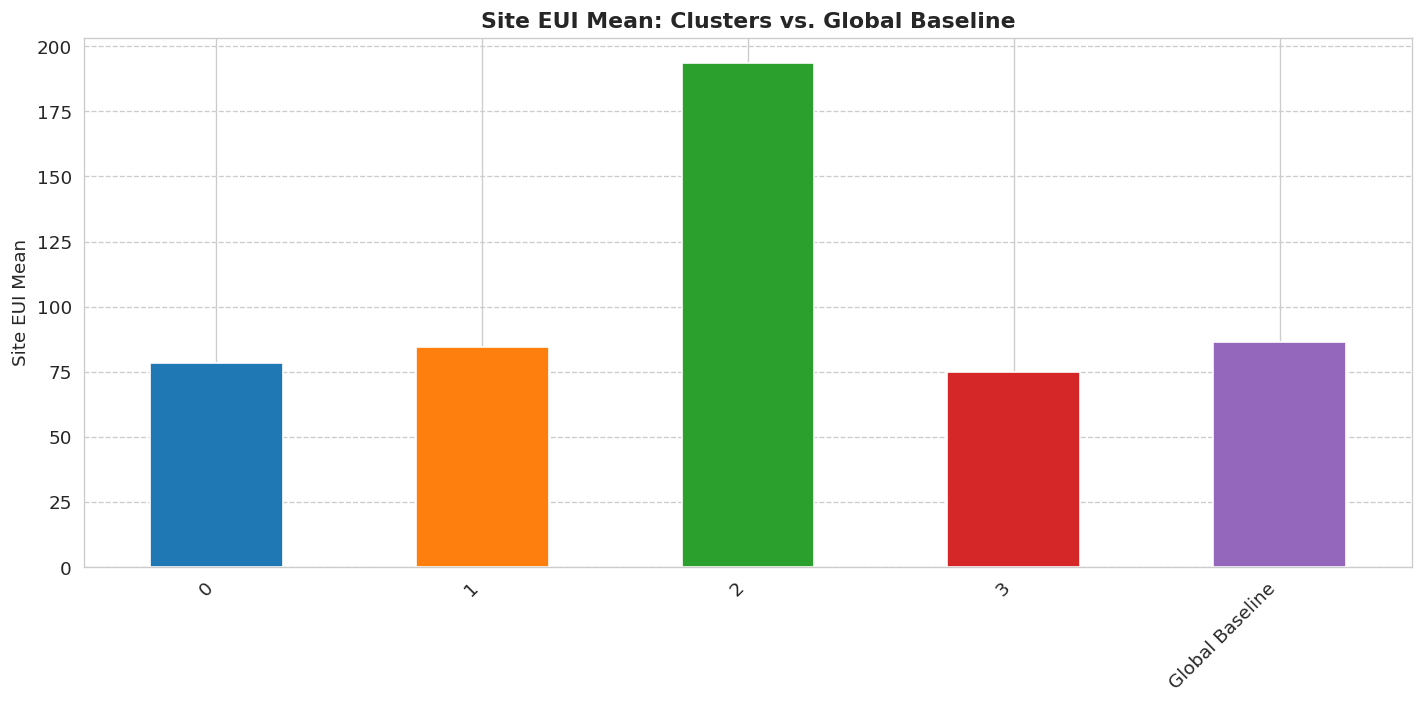

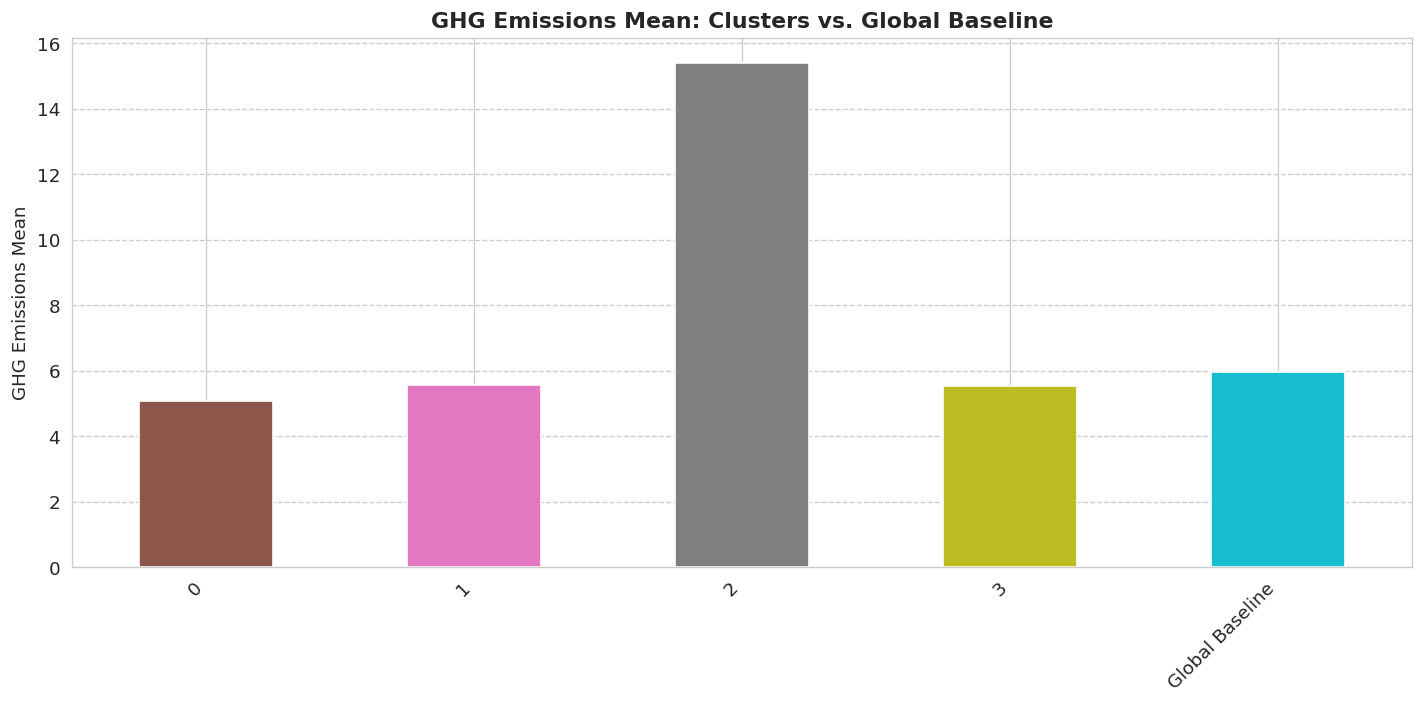

In [18]:
# Create a dictionary to hold the flattened global baseline values for the benchmarking metrics
global_baseline_flattened_benchmarking = {}
for metric in benchmarking_metrics:
    global_baseline_flattened_benchmarking[f'{metric}_mean'] = global_baseline.loc[metric, 'Mean']
    global_baseline_flattened_benchmarking[f'{metric}_std']  = global_baseline.loc[metric, 'Std']

# Changing the dictionary to a DataFrame row with a suitable index name for comparison
global_baseline_df_row_benchmarking = pd.DataFrame([global_baseline_flattened_benchmarking], index=['Global Baseline'])

# Creating a DataFrame for comparison by concatenating cluster_summary_benchmarking and the global_baseline_df_row_benchmarking
comparison_df_global = pd.concat([cluster_summary_benchmarking, global_baseline_df_row_benchmarking])

print('Comparison with Global Baseline (Benchmarking Metrics):')
display(comparison_df_global)

# Visualize the comparison for 'site_eui' mean
plt.figure(figsize=(12, 6))
comparison_df_global['site_eui_mean'].plot(kind='bar', color=PALETTE)
plt.title('Site EUI Mean: Clusters vs. Global Baseline', fontweight='bold')
plt.ylabel('Site EUI Mean')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

# Visualizing the comparison for 'ghg_emissions_int' mean
plt.figure(figsize=(12, 6))
comparison_df_global['ghg_emissions_int_mean'].plot(kind='bar', color=PALETTE[len(PALETTE) // 2:])
plt.title('GHG Emissions Mean: Clusters vs. Global Baseline', fontweight='bold')
plt.ylabel('GHG Emissions Mean')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

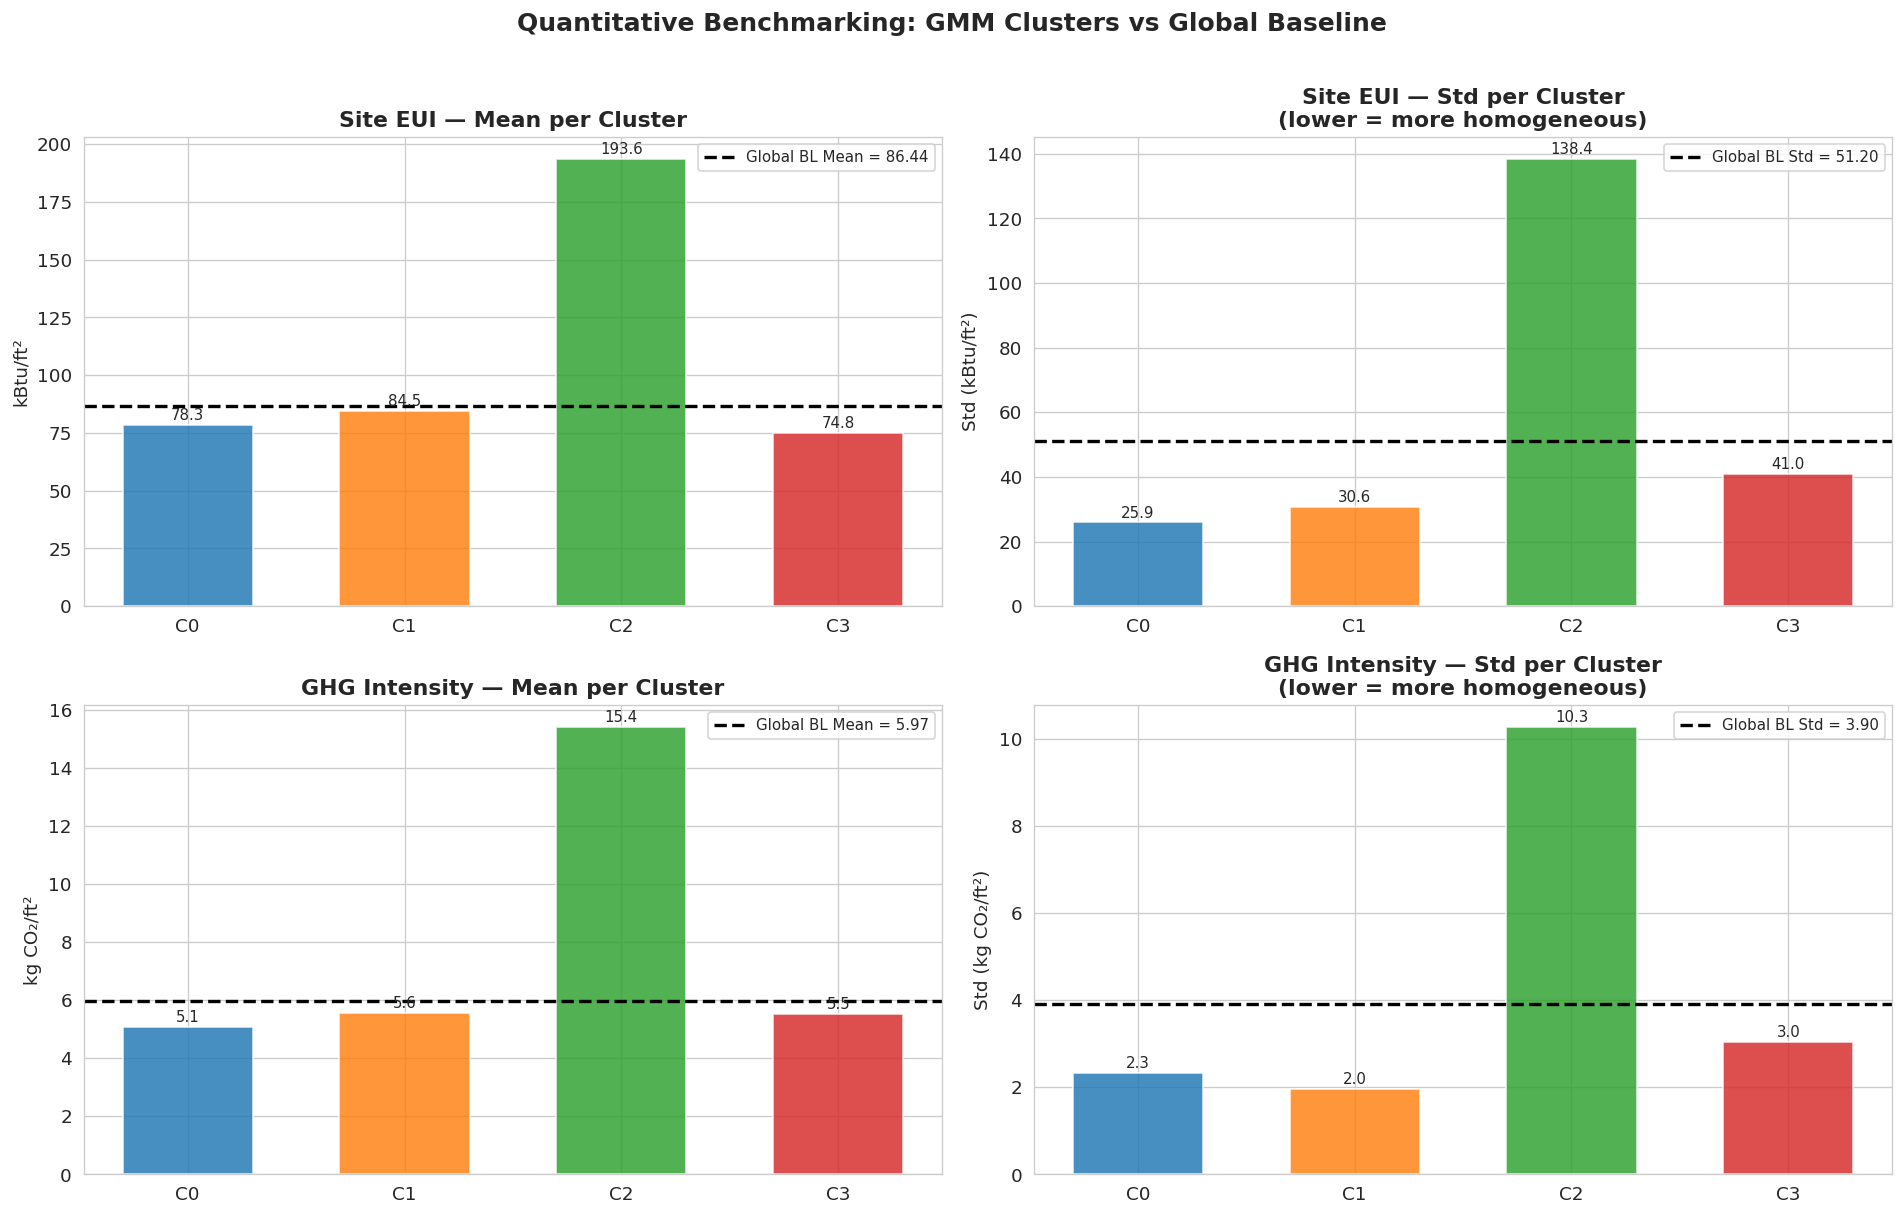

In [19]:
cluster_stats = cluster_summary_benchmarking
cluster_ids = cluster_stats.index.tolist()

# Extracting the global baseline values
g_eui_mean = global_baseline_df_row_benchmarking.loc['Global Baseline', 'site_eui_mean']
g_eui_std  = global_baseline_df_row_benchmarking.loc['Global Baseline', 'site_eui_std']
g_ghg_mean = global_baseline_df_row_benchmarking.loc['Global Baseline', 'ghg_emissions_int_mean']
g_ghg_std  = global_baseline_df_row_benchmarking.loc['Global Baseline', 'ghg_emissions_int_std']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

def bar_vs_baseline(ax, col, bval, blabel, ylabel, title):
    vals   = [cluster_stats.loc[c, col] for c in cluster_ids]
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(cluster_ids))]
    bars   = ax.bar([f'C{c}' for c in cluster_ids], vals, color=colors, alpha=0.82, width=0.6)
    ax.axhline(bval, color='black', linestyle='--', linewidth=2,
               label=f'{blabel} = {bval:.2f}')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bval * 0.012,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9)

bar_vs_baseline(axes[0,0], 'site_eui_mean',          g_eui_mean, 'Global BL Mean', 'kBtu/ft²',       'Site EUI — Mean per Cluster')
bar_vs_baseline(axes[0,1], 'site_eui_std',           g_eui_std,  'Global BL Std',  'Std (kBtu/ft²)', 'Site EUI — Std per Cluster\n(lower = more homogeneous)')
bar_vs_baseline(axes[1,0], 'ghg_emissions_int_mean', g_ghg_mean, 'Global BL Mean', 'kg CO₂/ft²',     'GHG Intensity — Mean per Cluster')
bar_vs_baseline(axes[1,1], 'ghg_emissions_int_std',  g_ghg_std,  'Global BL Std',  'Std (kg CO₂/ft²)','GHG Intensity — Std per Cluster\n(lower = more homogeneous)')

fig.suptitle('Quantitative Benchmarking: GMM Clusters vs Global Baseline',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

FComparing with the facility baseline:

Dominant Facility Types per Cluster:


facility_type,Commercial - Other,Commercial - Unknown,Data Center,Education - College or university,Education - Other classroom,Education - Preschool or daycare,Education - Uncategorized,Food Sales,Food Service - Fast food,Food Service - Other,Food Service - Restaurant or cafeteria,Food Service - Uncategorized,Grocery store or food market,Health Care - Inpatient,Health Care - Outpatient Clinic,Health Care - Outpatient Uncategorized,Health Care - Uncategorized,Industrial,Laboratory,Lodging - Dormitory or fraternity/sorority,Lodging - Hotel,Lodging - Other,Lodging - Uncategorized,Mixed Use - Commercial and Residential,Multifamily - Uncategorized,Nursing Home,Office - Bank or other financial,Office - Medical non diagnostic,Office - Uncategorized,Parking Garage,Public Assembly - Arena,Public Assembly - Drama theater,Public Assembly - Entertainment/culture,Public Assembly - Library,Public Assembly - Movie Theater,Public Assembly - Other,Public Assembly - Recreation,Public Assembly - Social/meeting,Public Assembly - Stadium,Public Assembly - Uncategorized,Public Safety - Courthouse,Public Safety - Fire or police station,Public Safety - Penitentiary,Religious worship,Retail - Enclosed mall,Retail - Strip shopping mall,Retail - Uncategorized,Retail - Vehicle dealership/showroom,Service - Dry-cleaning or Laundry,Service - Other service,Service - Post office or postal center,Service - Vehicle service/repair shop,Single Family - Uncategorized,Transportation Terminal,Warehouse - Distribution or Shipping center,Warehouse - Non-refrigerated,Warehouse - Refrigerated,Warehouse - Self-storage
cluster_k4,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,1.80%,77.84%,0.00%,0.00%,0.00%,20.36%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
1,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2,2.22%,0.00%,4.88%,4.19%,2.15%,0.03%,0.03%,0.18%,0.00%,0.00%,0.28%,0.19%,3.06%,5.65%,0.95%,0.13%,1.46%,4.21%,1.79%,0.73%,3.79%,0.85%,0.01%,11.26%,16.31%,2.06%,3.53%,1.43%,10.65%,1.10%,0.13%,0.51%,1.09%,0.58%,0.13%,1.12%,0.00%,0.19%,0.18%,0.01%,1.06%,1.01%,0.12%,0.45%,0.21%,1.31%,2.21%,0.04%,0.00%,0.07%,0.00%,3.19%,0.07%,0.25%,0.84%,1.79%,0.24%,0.04%
3,1.70%,0.01%,0.10%,1.99%,11.30%,2.66%,0.10%,0.13%,0.00%,0.02%,0.09%,0.10%,0.27%,0.45%,0.59%,0.15%,0.05%,4.17%,0.08%,2.34%,5.98%,1.38%,0.01%,0.00%,0.00%,2.84%,0.31%,1.78%,32.48%,1.76%,0.00%,0.90%,0.53%,2.09%,0.12%,0.63%,0.11%,0.53%,0.00%,0.00%,0.35%,2.97%,0.07%,2.47%,0.15%,0.82%,2.98%,0.28%,0.00%,0.18%,0.01%,1.53%,0.00%,0.08%,1.60%,5.67%,0.46%,2.61%



Comparison with Facility Baseline (Dominant Type):


,Cluster,Dominant Facility Type,Cluster Site EUI Mean,Baseline Site EUI Mean,Cluster GHG Mean,Baseline GHG Mean
0,0,Multifamily - Uncategorized,78.330331,84.86,5.071275,5.55
1,1,Multifamily - Uncategorized,84.491882,84.86,5.553816,5.55
2,2,Multifamily - Uncategorized,193.593886,84.86,15.402949,5.55
3,3,Office - Uncategorized,74.798415,77.69,5.533151,6.17


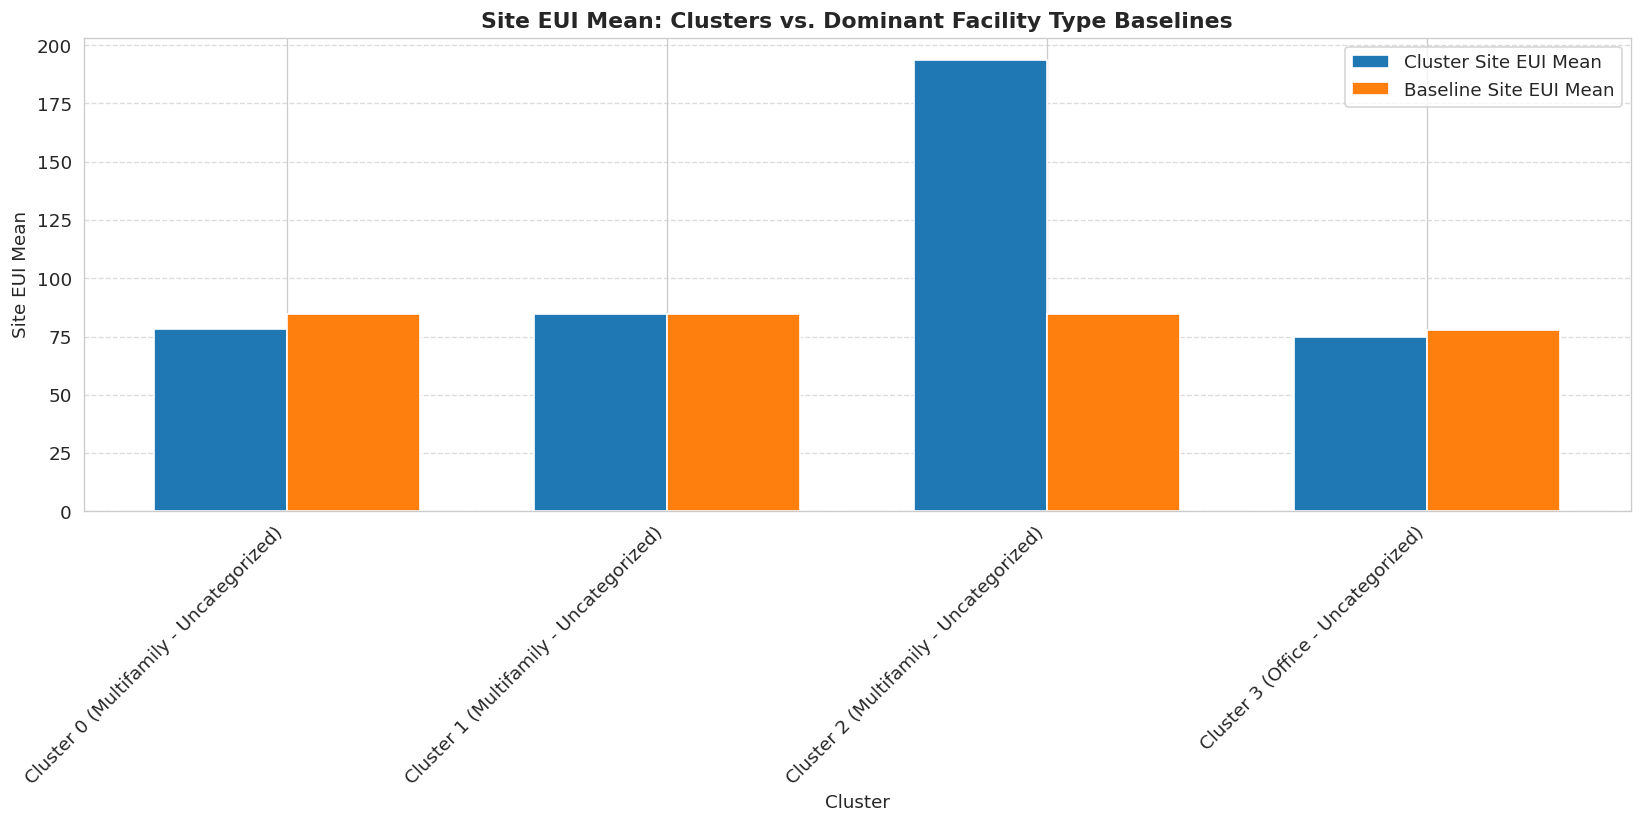

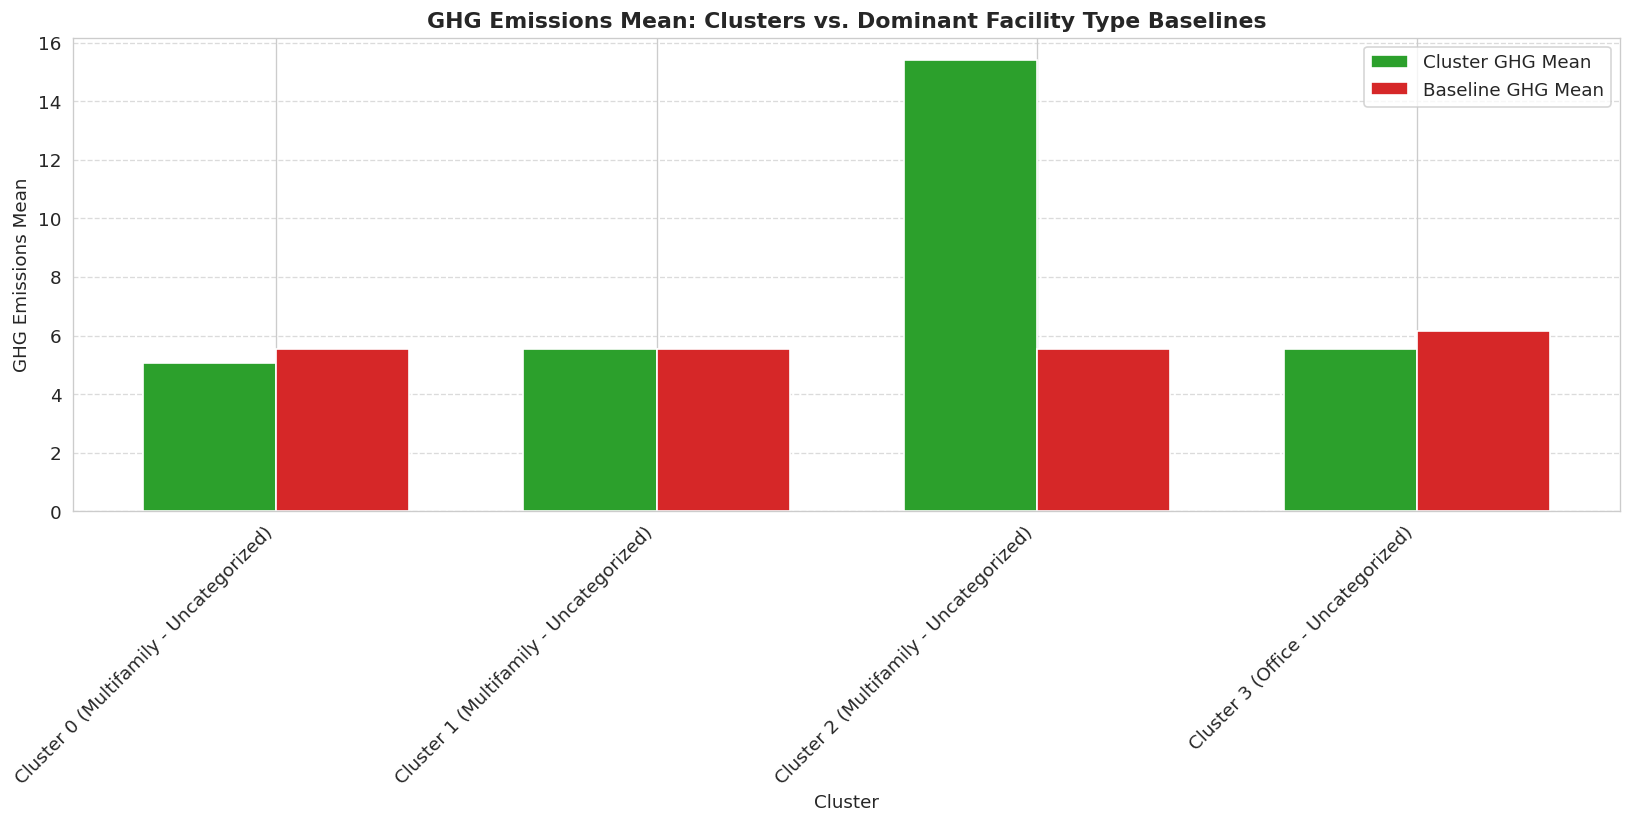

In [21]:

# Finding the dominant facility types within each cluster.
cluster_facility_distribution = clean_data.groupby('cluster_k4')['facility_type'].value_counts(normalize=True).unstack(fill_value=0)
print('Dominant Facility Types per Cluster:')
display(cluster_facility_distribution.style.format('{:.2%}'))

# Compare each cluster's performance with its dominant facility type's baseline
comparison_with_facility_baseline = pd.DataFrame()

for cluster_id in cluster_summary_benchmarking.index:
    dominant_ft = cluster_facility_distribution.loc[cluster_id].idxmax()

    # Getting the baseline for the dominant facility type
    baseline_row = facility_baseline[facility_baseline['facility_type'] == dominant_ft]

    if not baseline_row.empty:
        cluster_mean_site_eui = cluster_summary_benchmarking.loc[cluster_id, 'site_eui_mean']
        baseline_mean_site_eui = baseline_row['site_eui_mean'].values[0]

        cluster_mean_ghg = cluster_summary_benchmarking.loc[cluster_id, 'ghg_emissions_int_mean']
        baseline_mean_ghg = baseline_row['ghg_emissions_int_mean'].values[0]

        comparison_with_facility_baseline = pd.concat([
            comparison_with_facility_baseline,
            pd.DataFrame({
                'Cluster': [cluster_id],
                'Dominant Facility Type': [dominant_ft],
                'Cluster Site EUI Mean': [cluster_mean_site_eui],
                'Baseline Site EUI Mean': [baseline_mean_site_eui],
                'Cluster GHG Mean': [cluster_mean_ghg],
                'Baseline GHG Mean': [baseline_mean_ghg]
            })
        ], ignore_index=True)
    else:
        print(f"No facility baseline found for dominant type '{dominant_ft}' in Cluster {cluster_id}")

print('\nComparison with Facility Baseline (Dominant Type):')
display(comparison_with_facility_baseline)

# Visualizing the comparisosn for Site EUI mean
fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.35
index = np.arange(len(comparison_with_facility_baseline))

bar1 = ax.bar(index - bar_width/2, comparison_with_facility_baseline['Cluster Site EUI Mean'], bar_width, label='Cluster Site EUI Mean', color=PALETTE[0])
bar2 = ax.bar(index + bar_width/2, comparison_with_facility_baseline['Baseline Site EUI Mean'], bar_width, label='Baseline Site EUI Mean', color=PALETTE[1])

ax.set_xlabel('Cluster')
ax.set_ylabel('Site EUI Mean')
ax.set_title('Site EUI Mean: Clusters vs. Dominant Facility Type Baselines', fontweight='bold')
ax.set_xticks(index)
ax.set_xticklabels([f"Cluster {row['Cluster']} ({row['Dominant Facility Type']})" for idx, row in comparison_with_facility_baseline.iterrows()], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Visualize the comparison for GHG Emissions mean
fig, ax = plt.subplots(figsize=(14, 7))
bar1 = ax.bar(index - bar_width/2, comparison_with_facility_baseline['Cluster GHG Mean'], bar_width, label='Cluster GHG Mean', color=PALETTE[2])
bar2 = ax.bar(index + bar_width/2, comparison_with_facility_baseline['Baseline GHG Mean'], bar_width, label='Baseline GHG Mean', color=PALETTE[3])

ax.set_xlabel('Cluster')
ax.set_ylabel('GHG Emissions Mean')
ax.set_title('GHG Emissions Mean: Clusters vs. Dominant Facility Type Baselines', fontweight='bold')
ax.set_xticks(index)
ax.set_xticklabels([f"Cluster {row['Cluster']} ({row['Dominant Facility Type']})" for idx, row in comparison_with_facility_baseline.iterrows()], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Calculate Average Coefficient of Variation (Av CV) for All Clusters

In [22]:
# Initializing lists to store the individual CVs for each metric per cluster
all_clusters_site_eui_cv = []
all_clusters_ghg_cv = []

# Iterate through each cluster in the summary benchmarking DataFrame
for cluster_id in cluster_summary_benchmarking.index:
    cluster_stats = cluster_summary_benchmarking.loc[cluster_id]

    # Calculate Coefficient of Variation (CV) for site_eui
    mean_site_eui = cluster_stats['site_eui_mean']
    std_site_eui  = cluster_stats['site_eui_std']
    # Avoid division by zero if mean_site_eui is 0, though unlikely for EUI
    cv_site_eui   = (std_site_eui / mean_site_eui) if mean_site_eui != 0 else 0

    # Calculate Coefficient of Variation (CV) for ghg_emissions_int
    mean_ghg = cluster_stats['ghg_emissions_int_mean']
    std_ghg  = cluster_stats['ghg_emissions_int_std']
    # Avoid division by zero if mean_ghg is 0, though unlikely for GHG
    cv_ghg   = (std_ghg / mean_ghg) if mean_ghg != 0 else 0

    # Appending the  individual CVs to their respective lists
    all_clusters_site_eui_cv.append(cv_site_eui)
    all_clusters_ghg_cv.append(cv_ghg)

    # Calculating Average CV for the current cluster (still useful to show)
    avg_cv_cluster = (cv_site_eui + cv_ghg) / 2

    print(f"Cluster {cluster_id}: Site EUI CV = {cv_site_eui:.2f}, GHG Emissions CV = {cv_ghg:.2f}, Average CV = {avg_cv_cluster:.2f}")

# Calculating the overall average CV for site_eui and ghg_emissions_int across all clusters
overall_average_site_eui_cv = np.mean(all_clusters_site_eui_cv)
overall_average_ghg_cv = np.mean(all_clusters_ghg_cv)

print(f"\nOverall Average Site EUI CV across all clusters: {overall_average_site_eui_cv:.2f}")
print(f"Overall Average GHG Emissions CV across all clusters: {overall_average_ghg_cv:.2f}")

Cluster 0: Site EUI CV = 0.33, GHG Emissions CV = 0.46, Average CV = 0.40
Cluster 1: Site EUI CV = 0.36, GHG Emissions CV = 0.35, Average CV = 0.36
Cluster 2: Site EUI CV = 0.71, GHG Emissions CV = 0.67, Average CV = 0.69
Cluster 3: Site EUI CV = 0.55, GHG Emissions CV = 0.55, Average CV = 0.55

Overall Average Site EUI CV across all clusters: 0.49
Overall Average GHG Emissions CV across all clusters: 0.51


### Calculate Average Standard Deviation (Avg Std) for All Clusters

In [23]:
all_clusters_site_eui_std = []
all_clusters_ghg_std = []

for cluster_id in cluster_summary_benchmarking.index:
    cluster_stats = cluster_summary_benchmarking.loc[cluster_id]

    std_site_eui = cluster_stats['site_eui_std']
    std_ghg = cluster_stats['ghg_emissions_int_std']

    all_clusters_site_eui_std.append(std_site_eui)
    all_clusters_ghg_std.append(std_ghg)

    avg_std_cluster = (std_site_eui + std_ghg) / 2

    print(f"Cluster {cluster_id}: Site EUI Std = {std_site_eui:.2f}, GHG Emissions Std = {std_ghg:.2f}, Average Std = {avg_std_cluster:.2f}")

overall_average_site_eui_std = np.mean(all_clusters_site_eui_std)
overall_average_ghg_std = np.mean(all_clusters_ghg_std)
overall_average_std = (overall_average_site_eui_std + overall_average_ghg_std) / 2

print(f"\nOverall Average Site EUI Std across all clusters: {overall_average_site_eui_std:.2f}")
print(f"Overall Average GHG Emissions Std across all clusters: {overall_average_ghg_std:.2f}")
print(f"Overall Average Std across all clusters: {overall_average_std:.2f}")

Cluster 0: Site EUI Std = 25.92, GHG Emissions Std = 2.34, Average Std = 14.13
Cluster 1: Site EUI Std = 30.60, GHG Emissions Std = 1.96, Average Std = 16.28
Cluster 2: Site EUI Std = 138.37, GHG Emissions Std = 10.27, Average Std = 74.32
Cluster 3: Site EUI Std = 41.01, GHG Emissions Std = 3.05, Average Std = 22.03

Overall Average Site EUI Std across all clusters: 58.98
Overall Average GHG Emissions Std across all clusters: 4.40
Overall Average Std across all clusters: 31.69


### Detailed Cluster Summary

In [28]:
total_buildings = len(clean_data)

# Ensure cluster_stats is the full DataFrame for correct indexing
cluster_stats = cluster_summary_benchmarking
# Ensure cluster_ids is correctly populated from the DataFrame
cluster_ids = cluster_stats.index.tolist()

print('Detailed Cluster Analysis relative to the global baseline:')
for cluster_id in cluster_ids:
    # Cluster statistics
    c_site_eui_mean = cluster_stats.loc[cluster_id, 'site_eui_mean']
    c_ghg_mean = cluster_stats.loc[cluster_id, 'ghg_emissions_int_mean']
    c_site_eui_std = cluster_stats.loc[cluster_id, 'site_eui_std']

    # Global Baseline for comparison
    delta_site_eui = c_site_eui_mean - g_eui_mean
    delta_ghg = c_ghg_mean - g_ghg_mean

    # Determine energy performance category
    if delta_site_eui < -10 and delta_ghg < -0.5:
        performance_category = 'Highly Efficient (Low Energy)'
    elif delta_site_eui < 0 and delta_ghg < 0:
        performance_category = 'Moderately Efficient'
    elif delta_site_eui > 10 or delta_ghg > 2:
        performance_category = 'High Energy / Inefficient'
    elif delta_site_eui > 0 or delta_ghg > 0:
        performance_category = 'Above-Average Energy Use'
    else:
        performance_category = 'Average Performance'

    print(f'\n--- Cluster {cluster_id} [{performance_category}] ---')

    # Clusters size
    cluster_size = clean_data[clean_data['cluster_k4'] == cluster_id].shape[0]
    cluster_percentage = (cluster_size / total_buildings) * 100
    print(f'  Size              : {cluster_size:,} buildings ({cluster_percentage:.1f}%)')

    # Dominant facilities type
    dominant_ft = comparison_with_facility_baseline[comparison_with_facility_baseline['Cluster'] == cluster_id]['Dominant Facility Type'].values[0]
    print(f'  Dominant Type     : {dominant_ft}')

    print(f'  Mean Site EUI     : {c_site_eui_mean:.2f}  (Global BL: {g_eui_mean:.2f}, Δ={delta_site_eui:+.2f})')
    print(f'  Mean GHG Intensity: {c_ghg_mean:.2f}  (Global BL: {g_ghg_mean:.2f}, Δ={delta_ghg:+.2f})')
    print(f'  Site EUI Std      : {c_site_eui_std:.2f}  (Global BL Std: {g_eui_std:.2f})')

Detailed Cluster Analysis relative to the global baseline:

--- Cluster 0 [Moderately Efficient] ---
  Size              : 17,339 buildings (12.8%)
  Dominant Type     : Multifamily - Uncategorized
  Mean Site EUI     : 78.33  (Global BL: 86.44, Δ=-8.11)
  Mean GHG Intensity: 5.07  (Global BL: 5.97, Δ=-0.90)
  Site EUI Std      : 25.92  (Global BL Std: 51.20)

--- Cluster 1 [Moderately Efficient] ---
  Size              : 74,534 buildings (54.9%)
  Dominant Type     : Multifamily - Uncategorized
  Mean Site EUI     : 84.49  (Global BL: 86.44, Δ=-1.95)
  Mean GHG Intensity: 5.55  (Global BL: 5.97, Δ=-0.42)
  Site EUI Std      : 30.60  (Global BL Std: 51.20)

--- Cluster 2 [High Energy / Inefficient] ---
  Size              : 6,706 buildings (4.9%)
  Dominant Type     : Multifamily - Uncategorized
  Mean Site EUI     : 193.59  (Global BL: 86.44, Δ=+107.15)
  Mean GHG Intensity: 15.40  (Global BL: 5.97, Δ=+9.43)
  Site EUI Std      : 138.37  (Global BL Std: 51.20)

--- Cluster 3 [Moderate

We identified three clusters (0, 1, and 3) that show relatively a good performance, as its Site EUI and GHG emissions that are close to or better than the global average. These clusters also show good consistency within their groups. However, Cluster 2 performs poorly, with much higher energy use and emissions, as well as greater variation among its buildings. This makes Cluster 2 an important target for future energy‑efficiency improvements.